In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')
sns.set_palette('deep')
 # importing the data
nhts_data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')

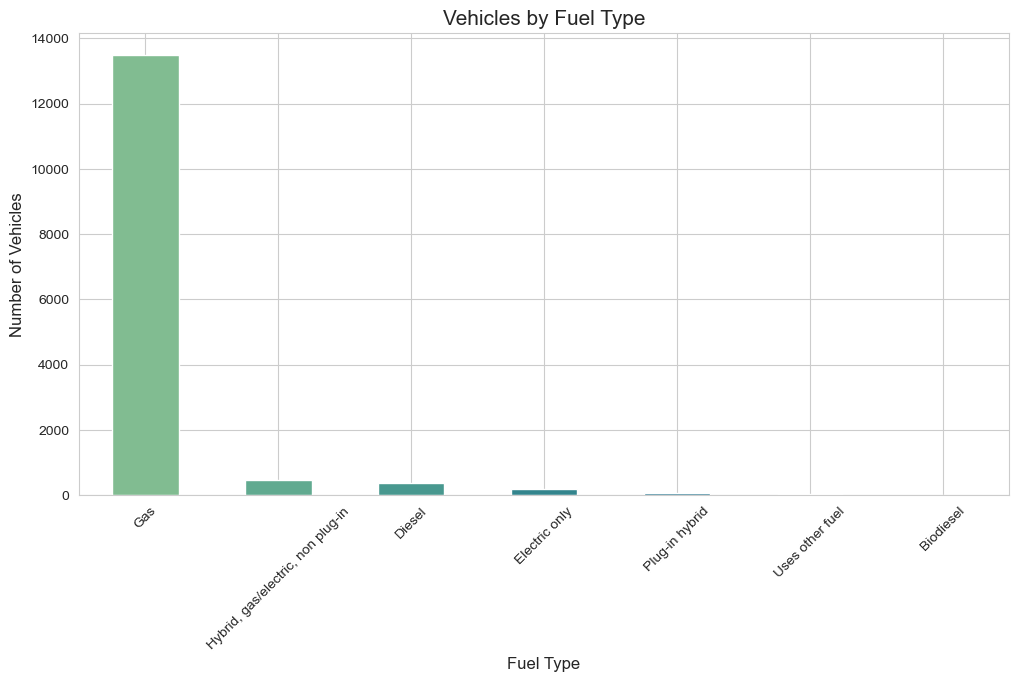

In [3]:

fuel_counts = nhts_data['fuel_type'].value_counts().dropna()

plt.figure(figsize = (12,6))

fuel_counts.plot(kind = 'bar', color = sns.color_palette('crest',len(fuel_counts)),)

## add labels and customization
plt.title('Vehicles by Fuel Type', fontsize=15)
plt.xlabel('Fuel Type', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.savefig("bar.png", dpi = 300, bbox_inches="tight")
plt.show()

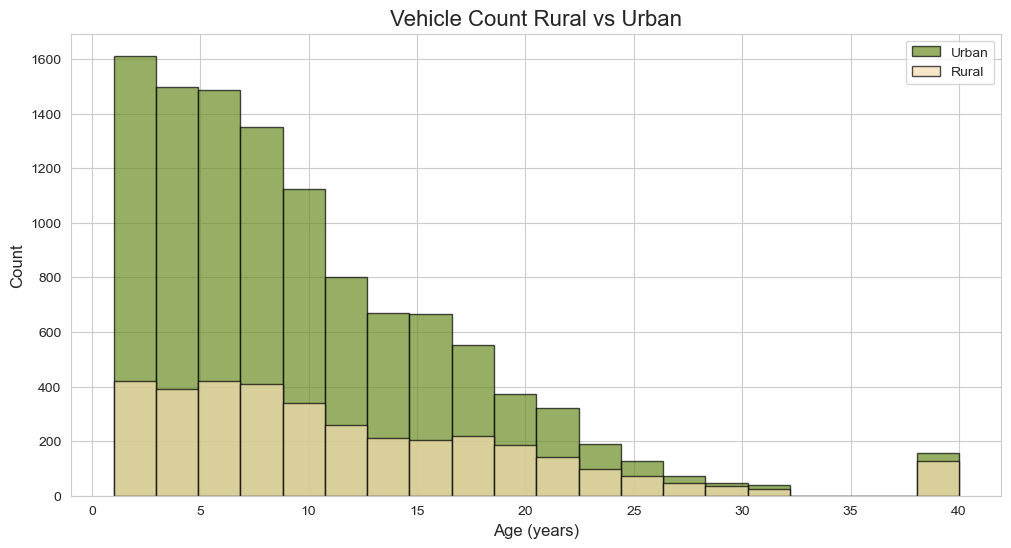

In [4]:
plt.figure(figsize = (12,6))

urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(urban_ages, bins = 20, edgecolor = 'black', alpha = 0.7, color='olivedrab', label = 'Urban')


rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 20, edgecolor = 'black', alpha = 0.7, color='wheat', label = 'Rural')

plt.title('Vehicle Count Rural vs Urban', fontsize=16)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.savefig("histo.png", dpi = 300, bbox_inches="tight")
plt.show()


C:\Users\gmrot\AppData\Local\Temp\ipykernel_24556\710648845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( data = nhts_data, y = 'vehicle_age', x = 'make', palette='muted')


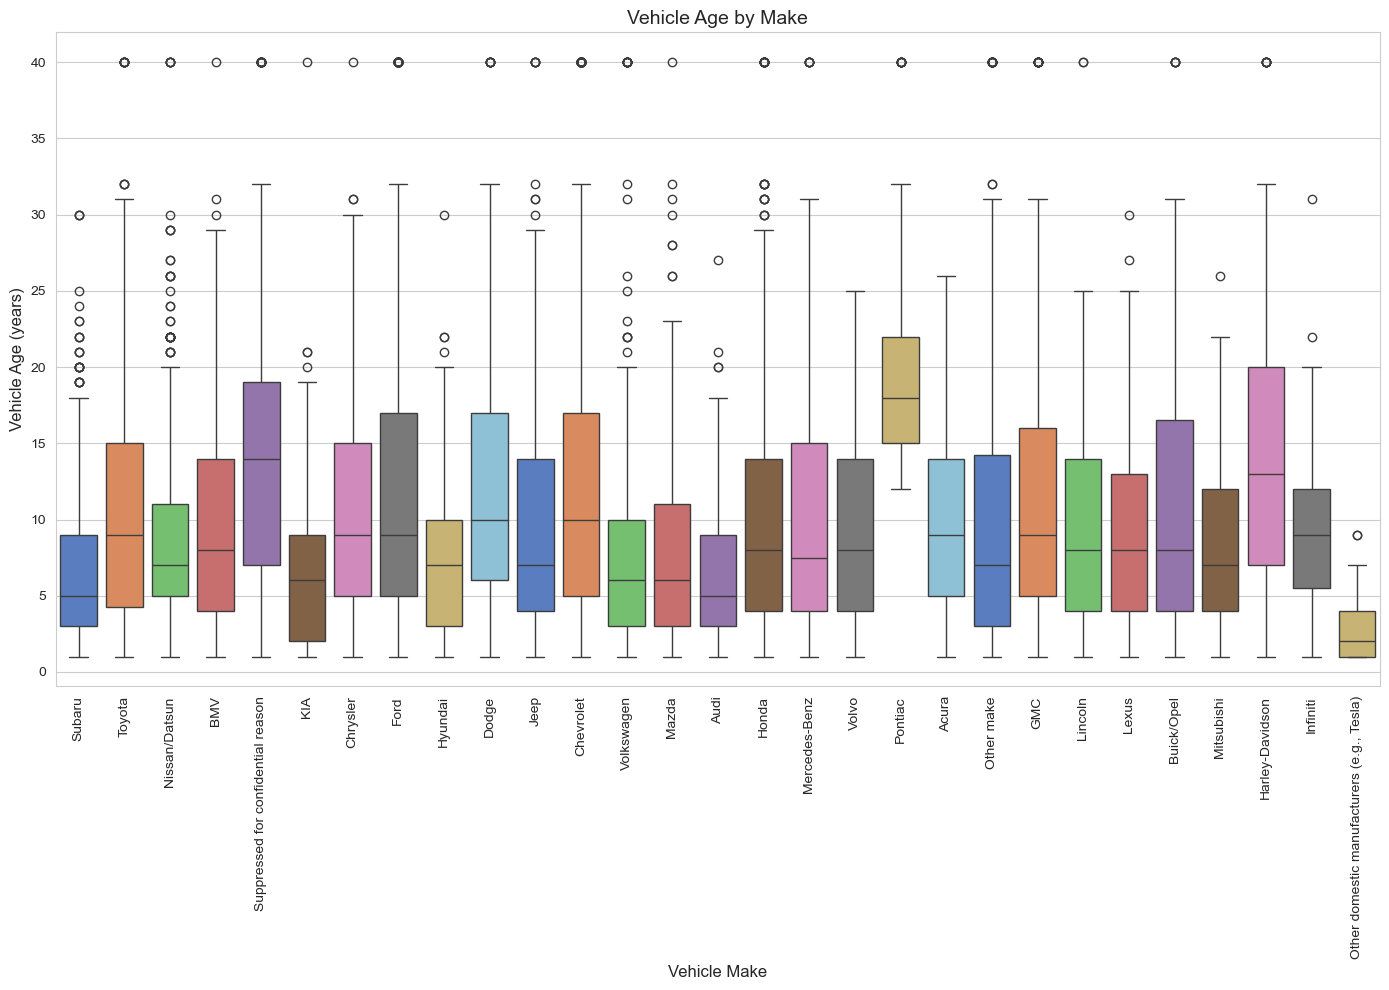

In [5]:
plt.figure(figsize = (14,10))

sns.boxplot( data = nhts_data, y = 'vehicle_age', x = 'make', palette='muted')

plt.xticks(rotation = 90)

plt.xlabel('Vehicle Make', fontsize = 12)
plt.ylabel('Vehicle Age (years)', fontsize = 12)
plt.title('Vehicle Age by Make', fontsize = 14)

plt.tight_layout()
plt.savefig("boxplot.png", dpi = 300, bbox_inches="tight")
plt.show()

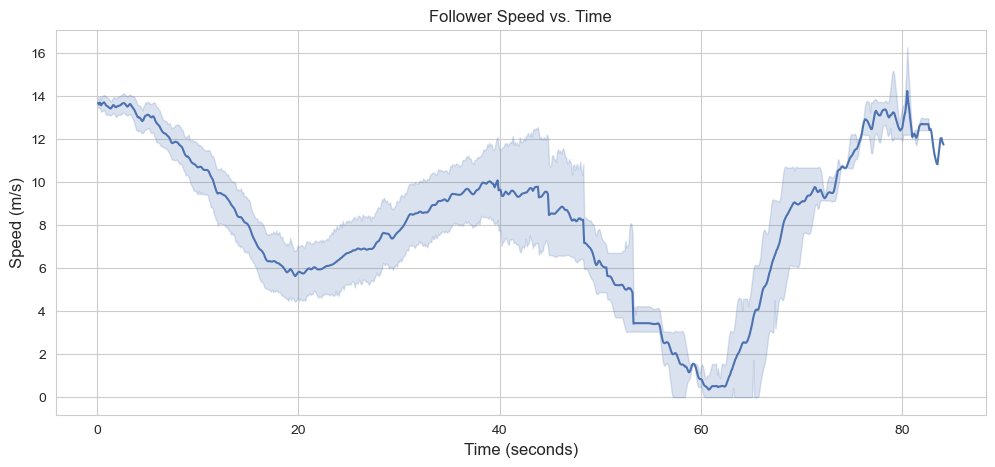

In [6]:
plt.figure(figsize=(12,5))

sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_speed(m/s)'])
# add customizations
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.title('Follower Speed vs. Time', fontsize=12)
plt.savefig("speedtime.png", dpi = 300, bbox_inches="tight")
plt.show()

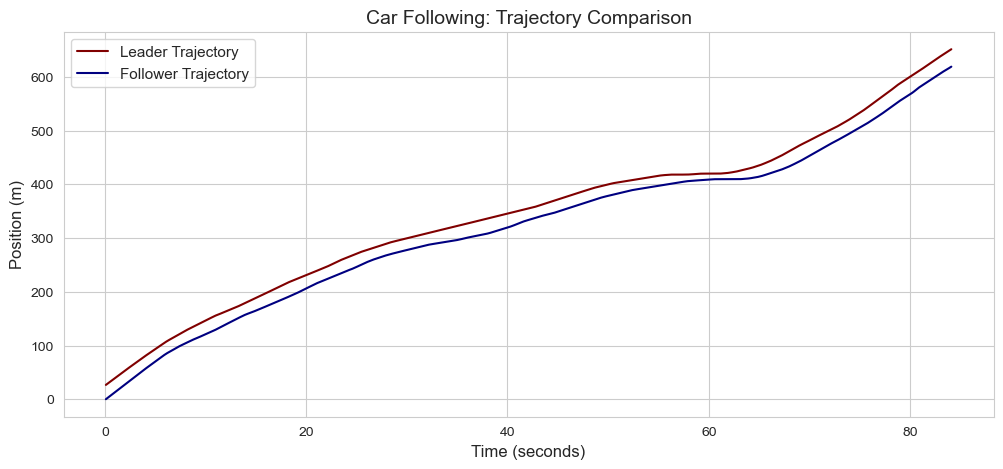

In [7]:
trajectory_number = 1

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Plot the position of both vehicles over time
plt.figure(figsize=(12,5))
sns.lineplot(x = data_subset['Time'], y = data_subset['leader_position(m)'], label = 'Leader Trajectory', color = 'maroon')
sns.lineplot(x = data_subset['Time'], y = data_subset['follower_position(m)'], label = 'Follower Trajectory', color = 'navy')

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Position (m)', fontsize=12)
plt.title('Car Following: Trajectory Comparison', fontsize = 14)

plt.legend(fontsize = 11)
plt.savefig("positiontime.png", dpi = 300, bbox_inches="tight")
plt.show()


Enter desired velocity (m/s):  40
Enter minimum spacing (m):  2
Enter desired time headway (s):  1.5
Enter maximum acceleration (m/s^2):  1
Enter comfortable deceleration (m/s^2):  1.5
Enter acceleration exponent (m/s):  5


Time step dt = 0.100 s
Simulation complete!


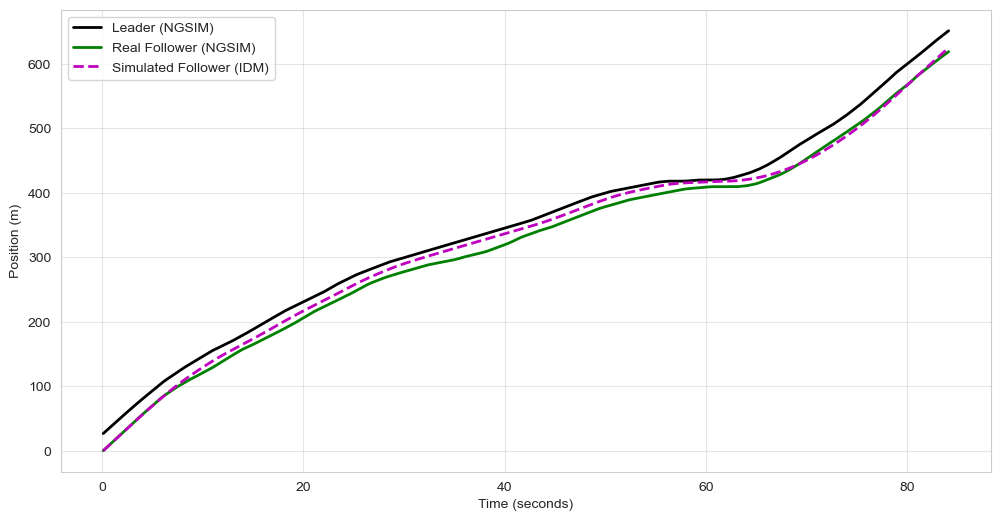

In [31]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**(delta) - (s_star/s)**2)
      
    return acceleration

# Test the IDM function with sample values
# A follower traveling at 20 m/s, with a gap of 25 m, approaching the leader at 2 m/s

# User input the IDM parameters
v0 = float(input('Enter desired velocity (m/s): '))
s0 = float(input('Enter minimum spacing (m): ')) 
T = float(input('Enter desired time headway (s): '))
a_param = float(input('Enter maximum acceleration (m/s^2): '))
b = float(input('Enter comfortable deceleration (m/s^2): '))
delta = float(input('Enter acceleration exponent (m/s): '))

# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair
trajectory_number = 1

# Extract the leader's position and speed over time
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)
leader_position = data_subset['leader_position(m)'].values
time_data = data_subset['Time'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = time_data[1] - time_data[0]
print(f'Time step dt = {dt:.3f} s')

# Initialize arrays to store simulation results
n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acceleration = np.zeros(n_steps)


# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]
        #this makes the starting value [0] same as the follower vehicle position
        #this makes the starting value [0] same as the follower vehicle speed

# Run the IDM simulation
for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acceleration[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = sim_speed[i] + sim_acceleration[i] * dt
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

print("Simulation complete!")

# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, 'k-', linewidth = 2, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_position(m)'].values, 'g-', linewidth = 2, label = 'Real Follower (NGSIM)')
plt.plot(time_data, sim_position, 'm--', linewidth = 2, label = 'Simulated Follower (IDM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.savefig("sim.png", dpi = 300, bbox_inches="tight")
plt.show()